In [5]:
import numpy as np
import matplotlib.pyplot as plt

import Voronoi as Voronoi
import MonteCarlo as MonteCarlo
import Graphene as Graphene
import LammpsWriter as LammpsWriter
import Run_anneal as Run_anneal
from Analyze_Observable import analyze_observable, plot_phase_diagram
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


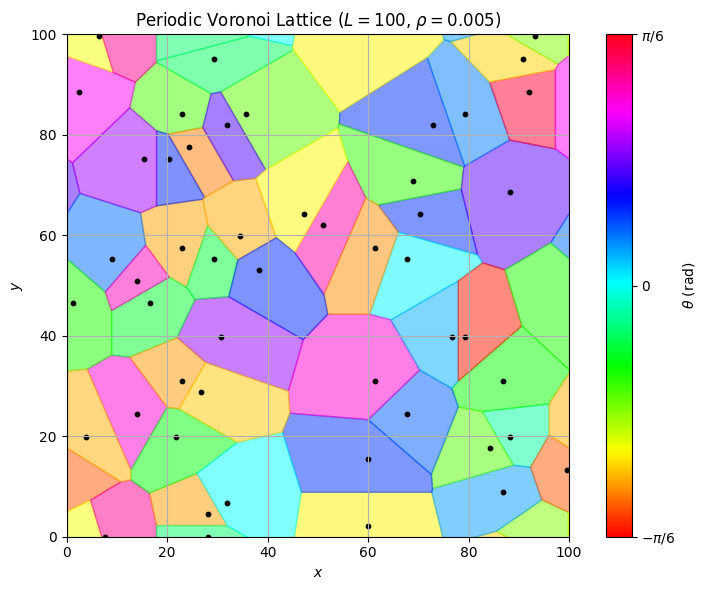

In [23]:
L = 100
rho = 0.005

vor = Voronoi.PeriodicVoronoi(L, rho)

vor.plot()
plt.show()

Monte Carlo Sweeps: 100%|██████████| 200000/200000 [00:00<00:00, 758084.61it/s]


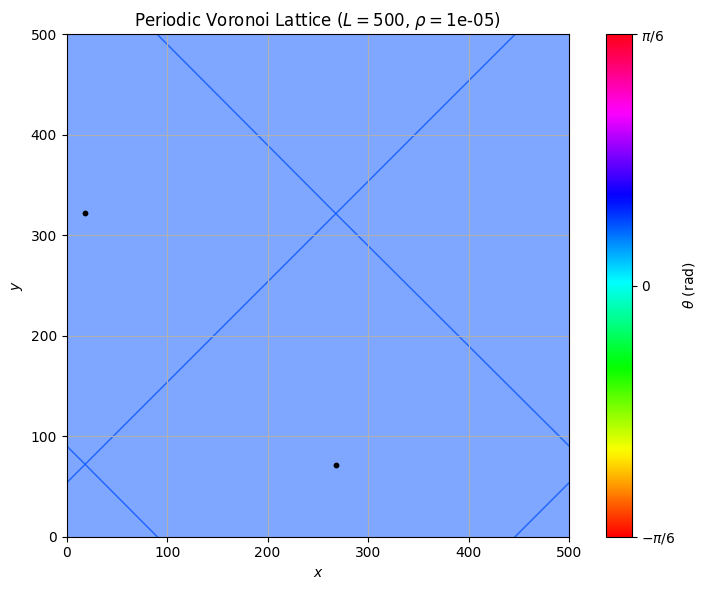

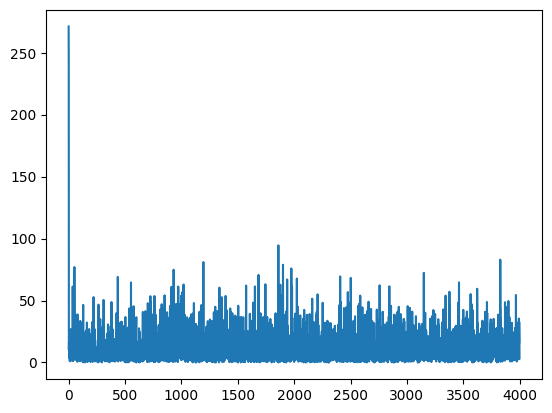

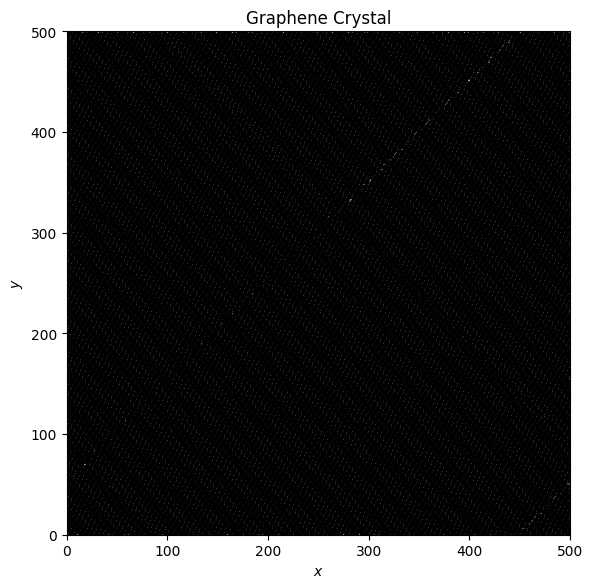

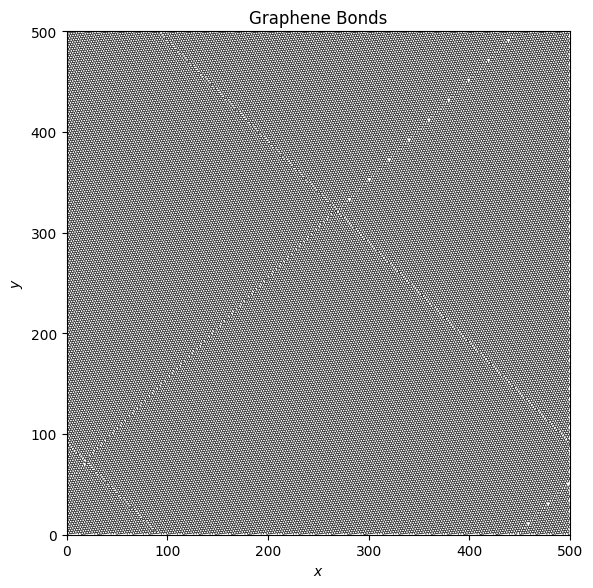

In [4]:
T = 10
L = 500
rho = 0.00001
alpha = 2.36
beta_RS = -0.12
epsilon = 0

vor = Voronoi.PeriodicVoronoi(L, rho)

thetas, energy = MonteCarlo.monte_carlo(vor.theta, vor.adj_i, vor.adj_j, vor.adj_length, 1/T, epsilon, rho, alpha, beta_RS, 200_000)
vor.theta = thetas
vor.plot()
plt.show()

plt.plot(energy)
plt.show()

graphene = Graphene.GrapheneCrystal(vor, a=1.42)
graphene.plot_atoms()
plt.show()
graphene.plot_bonds()
plt.show()

In [9]:
crystal = load_crystal("results/eps_0/L_3000/rho_1e-05/T_40/final_crystal.npz")
crystal.plot_atoms()
plt.show()
crystal.plot_bonds()
plt.show()

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1m[1mNo implementation of function Function(<built-in function len>) found for signature:
 
 >>> len(none)
 
There are 20 candidate implementations:
[1m - Of which 20 did not match due to:
 Overload of function 'len': File: <numerous>: Line N/A.
   With argument(s): '(none)':[0m
[1m  No match.[0m
[0m
[0m[1mDuring: resolving callee type: Function(<built-in function len>)[0m
[0m[1mDuring: typing of call at c:\Users\Alexi\Documents\TP\TP2\Simulation\Graphene.py (85)[0m
[1m
File "Graphene.py", line 85:[0m
[1mdef compute_neighbors(atoms, bonds):
    <source elided>
    neighbors = -np.ones((N, 3), dtype=np.int64)
[1m    for k in range(len(bonds)):
[0m    [1m^[0m[0m

[0m[1mDuring: Pass nopython_type_inference[0m

In [6]:
epsilon = 0

phase_data = {
    0.00001: {
        "T": [40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200],
        "phases": ["s", "s", "h", "h", "h", "h", "h", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.000005: {
        "T": [40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250],
        "phases": ["s", "s", "s", "s", "s", "s", "h", "h", "h", "h", "h", "h", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.000007: {
        "T": [40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250],
        "phases": ["s", "s", "s", "s", "h", "h", "h", "h", "h", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.00003: {
        "T": [30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150],
        "phases": ["s", "s", "h", "h", "l", "l", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.00005: {
        "T": [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120],
        "phases": ["s", "s", "h", "h", "l", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.001: {
        "T": [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
        "phases": ["s", "s", "s", "h", "h", "h", "l", "l", "l", "l", "l"]
    },
    0.0001: {
        "T": [10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100],
        "phases": ["s", "s", "h", "h", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.0002: {
        "T": [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60],
        "phases": ["s", "h", "h", "h", "l", "l", "l", "l", "l", "l", "l"]
    },
    0.0005: {
        "T": [7, 8, 10, 15, 20, 25, 30, 35, 40],
        "phases": ["s", "h", "h", "l", "l", "l", "l", "l", "l"]
    }
}

plot_phase_diagram(phase_data, epsilon)